# 05 — Comparación de detectores y decisión de diseño (Fase D)

Este notebook consume exclusivamente los artefactos OOS generados por
`04_benchmark_detectores.ipynb` (`results/benchmark_v2/metrics/*.csv` y
`manifest.json`). No vuelve a ajustar modelos, no modifica sus configuraciones y no
mezcla las pistas A y B en un ranking único.

> **Objetivo.** Resumir sensibilidad, especificidad, persistencia, estabilidad y
> coste; detectar dominancias y tensiones; comprobar si el ranking es robusto; y dejar
> una base auditable para decidir más adelante entre un detector único, un híbrido o
> un diseño nuevo. El notebook no declara automáticamente un ganador.

**Qué contiene:** carga y trazabilidad (§1), gate de comparabilidad y crisis realmente
evaluadas (§2), ranking descriptivo (§3), sensibilidad frente a especificidad con la
tasa base como referencia (§4), persistencia y estabilidad (§5), ranks por dimensión
(§6), cobertura por crisis (§7), robustez del ranking frente a líneas base triviales,
ejes y crisis (§8), limitaciones (§9) y lectura final (§10–§11).

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from IPython.display import display

warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'data' / 'benchmark_spec.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import benchmark as bm

OUTPUT_DIR = ROOT / 'results' / 'benchmark_v2'
SPEC = yaml.safe_load((ROOT / 'data' / 'benchmark_spec.yaml').read_text(encoding='utf-8'))
AXES = {  # eje del ranking -> True si "menor es mejor"
    'mean_crisis_coverage': False,
    'false_alarm_rate': True,
    'mean_trap_activation': True,
    'switching_rate': True,
    'label_stability': False,
}
pd.set_option('display.max_columns', 120)
print('Resultados:', OUTPUT_DIR.relative_to(ROOT))

Resultados: results\benchmark_v2


## 1. Carga, inventario y trazabilidad

Se espera una fila por pista y detector. Una comparación con menos de 12 detectores
puede usarse como diagnóstico, pero debe rotularse como **parcial** y no fundamentar
la decisión final. Las filas A y B nunca compiten directamente: A aporta profundidad
histórica y B riqueza multi-activo.

La carga intenta primero el modo estricto (`require_current=True`): recalcula la huella
de cada CSV con el código, los datos y el entorno locales y exige el panel OOS. Los
paneles OOS y los datos procesados no se versionan, así que en otra máquina esa
verificación puede fallar aunque las métricas sean las correctas. En ese caso se cargan
las métricas versionadas y se comprueba, sin datos locales, que cada CSV lleva la huella
que el `manifest.json` registró en la ejecución original. La tabla de trazabilidad deja
constancia de qué verificación se ha superado.

In [2]:
VERIFICACION_LOCAL = False
try:
    metrics = bm.load_metrics(OUTPUT_DIR)
    VERIFICACION_LOCAL = True
    HAY_RESULTADOS = True
except FileNotFoundError as exc:
    metrics = pd.DataFrame()
    HAY_RESULTADOS = False
    print(exc)
except RuntimeError as exc:
    print('Verificación local de huella no superada en esta máquina:')
    print('  ', str(exc)[:160], '...')
    print('Se usan las métricas versionadas y se verifica su procedencia contra manifest.json.')
    metrics = bm.load_metrics(OUTPUT_DIR, require_current=False)
    HAY_RESULTADOS = True

if HAY_RESULTADOS:
    provenance = bm.metrics_provenance(OUTPUT_DIR)
    TRAZABLE = bool(len(provenance) and provenance['coincide_manifest'].all())
    print('Ejecución registrada en manifest.json:', provenance.attrs.get('manifest_generated_utc'))
    print('CSV con huella = manifiesto:', int(provenance['coincide_manifest'].sum()), '/', len(provenance))
    print('Verificación local completa (código + datos + entorno):', VERIFICACION_LOCAL)

    inventario = metrics.groupby('pista')['id'].agg(['count', lambda s: ', '.join(sorted(s))])
    inventario.columns = ['n_detectores', 'ids']
    display(inventario)
    completo = metrics.groupby('pista')['id'].nunique().reindex(['A', 'B'], fill_value=0)
    BENCHMARK_COMPLETO = bool((completo == 12).all())
    print('Benchmark completo:', BENCHMARK_COMPLETO)
else:
    BENCHMARK_COMPLETO = False
    TRAZABLE = False

Verificación local de huella no superada en esta máquina:
   Hay métricas ausentes u obsoletas: A_D01.csv, A_D02.csv, A_D03.csv, A_D04.csv, A_D05.csv, A_D06.csv, A_D07.csv, A_D08.csv, A_D09.csv, A_D10.csv, A_D11.csv, A_D1 ...
Se usan las métricas versionadas y se verifica su procedencia contra manifest.json.
Ejecución registrada en manifest.json: 2026-08-30T16:58:14.108278+00:00
CSV con huella = manifiesto: 24 / 24
Verificación local completa (código + datos + entorno): False


,n_detectores,ids
pista,,
A,12,"D01, D02, D03, D04, D05, D06, D07, D08, D09, D..."
B,12,"D01, D02, D03, D04, D05, D06, D07, D08, D09, D..."


Benchmark completo: True


## 2. Gate de comparabilidad

Antes de ordenar métricas verificamos que dentro de cada pista todos los detectores
comparten inicio, fin y longitud OOS, que no hay duplicados `(pista, id)`, que la
ventana de entrenamiento declarada es común y que las métricas son trazables a la
ejecución registrada. Las distintas frecuencias de *refit* (21 sesiones en general, 63
en D5, 126 en D8/D11) son configuración computacional, no ventanas de evaluación
distintas; su efecto sobre `label_stability` se discute en §9.

Una discrepancia detiene la interpretación: no se arregla rellenando ni recortando
resultados después de verlos.

In [3]:
if HAY_RESULTADOS:
    duplicates = metrics.duplicated(['pista', 'id']).sum()
    checks = metrics.groupby('pista').agg(
        detectores=('id', 'nunique'),
        inicios_oos=('oos_start', 'nunique'),
        finales_oos=('oos_end', 'nunique'),
        longitudes_oos=('n_oos', 'nunique'),
        train_configs=('train_days', 'nunique'),
    )
    display(checks)
    print('Duplicados pista/id:', duplicates)
    COMPARABLE = bool(
        duplicates == 0
        and (checks[['inicios_oos', 'finales_oos', 'longitudes_oos', 'train_configs']] == 1).all().all()
    )
    print('Gate de comparabilidad:', 'OK' if COMPARABLE else 'FALLA')
    print('Trazabilidad CSV↔manifiesto:', 'OK' if TRAZABLE else 'FALLA')
else:
    COMPARABLE = False

LISTO_COMPARAR = bool(BENCHMARK_COMPLETO and COMPARABLE and TRAZABLE)
if HAY_RESULTADOS and not BENCHMARK_COMPLETO:
    print('Comparación final bloqueada: faltan detectores; termina primero el notebook 04.')

,detectores,inicios_oos,finales_oos,longitudes_oos,train_configs
pista,,,,,
A,12,1,1,1,1
B,12,1,1,1,1


Duplicados pista/id: 0
Gate de comparabilidad: OK
Trazabilidad CSV↔manifiesto: OK


### 2.1 Qué crisis se evalúan realmente fuera de muestra

`benchmark_spec.yaml` asigna 18 crisis a la pista A y 10 a la B, pero el primer
entrenamiento consume ocho años en A y tres en B. La tabla clasifica cada ventana
`[pico, suelo]` frente al rango OOS común: **completa**, **parcial** (el OOS empieza
dentro de la ventana) o **fuera** (NaN para todos los detectores; ni premia ni penaliza).
Los días son sesiones hábiles aproximadas (lunes–viernes), solo informativas.

In [4]:
def estado_ventanas(track):
    part = metrics[metrics.pista == track].iloc[0]
    oos_start, oos_end = pd.Timestamp(part.oos_start), pd.Timestamp(part.oos_end)
    rows = []
    for name, (a, b) in SPEC['crisis_windows'][f'pista_{track}'].items():
        a, b = pd.Timestamp(a), pd.Timestamp(b)
        dias = len(pd.bdate_range(a, b))
        dias_oos = len(pd.bdate_range(max(a, oos_start), min(b, oos_end))) if b >= oos_start else 0
        estado = 'fuera' if dias_oos == 0 else ('completa' if a >= oos_start else 'parcial')
        rows.append({'pista': track, 'crisis': name, 'inicio': a.date(), 'suelo': b.date(),
                     'dias_aprox': dias, 'dias_oos_aprox': dias_oos, 'estado': estado})
    return pd.DataFrame(rows)

if LISTO_COMPARAR:
    ventanas = pd.concat([estado_ventanas(t) for t in ['A', 'B']], ignore_index=True)
    resumen_ventanas = ventanas.groupby(['pista', 'estado']).size().unstack(fill_value=0)
    display(resumen_ventanas)
    display(ventanas[ventanas.estado != 'completa'])
    for t in ['A', 'B']:
        part = metrics[metrics.pista == t].iloc[0]
        print(f"Pista {t}: OOS {part.oos_start} → {part.oos_end} (n={part.n_oos} sesiones)")

estado,completa,fuera,parcial
pista,,,
A,16,1,1
B,9,1,0


,pista,crisis,inicio,suelo,dias_aprox,dias_oos_aprox,estado
0,A,credit_crunch_1966,1966-02-09,1966-10-07,173,0,fuera
1,A,bear_1969_70,1968-11-29,1970-05-26,388,11,parcial
18,B,gfc_2007_09,2007-10-09,2009-03-09,370,0,fuera


Pista A: OOS 1970-05-12 → 2026-05-29 (n=14133 sesiones)
Pista B: OOS 2010-04-12 → 2026-05-29 (n=4059 sesiones)


**Lectura.** A evalúa 17 episodios (16 completos y `bear_1969_70`, del que solo
entran sus últimos días, en torno al suelo); `credit_crunch_1966` queda fuera. B
evalúa 9: la GFC cae entera en el entrenamiento. Además los episodios son muy
desiguales: `volmageddon_2018q1` dura 10 sesiones y `dotcom_2000_02` más de 600, y
`mean_crisis_coverage` les da el mismo peso.

## 3. Métricas agregadas y ranking descriptivo

Definiciones (todas sobre las etiquetas OOS causales; `crisis` = estado canónico más
severo):

| eje | definición | mejor |
|---|---|---|
| `mean_crisis_coverage` | media por evento de la fracción de días de cada ventana `[pico, suelo]` marcados como crisis (sensibilidad por evento) | ↑ |
| `false_alarm_rate` | fracción de los días marcados como crisis que caen **fuera** de todas las ventanas: `1 − precisión`, no la tasa de falsos positivos clásica `FP/(FP+TN)` | ↓ |
| `mean_trap_activation` | fracción de días marcados como crisis en las trampas `taper_2013` y `debtceiling_2013` | ↓ |
| `switching_rate` | cambios de estado / nº de días OOS | ↓ |
| `label_stability` | acuerdo entre la etiqueta OOS de un bloque y la que le asigna el modelo del fold siguiente; con dos estimaciones por fecha vive en **[0,5; 1]** | ↑ |

Cada eje se ordena por separado dentro de la pista (empates = rango medio; NaN al
fondo) y `rank_medio` es su media simple; `puesto_pista` comparte puesto en empates.
La duración media se conserva como diagnóstico, pero no entra en el promedio: es una
transformación monótona del número de cambios y duplicaría el peso del switching.

Es un **mapa descriptivo**, no una función de utilidad definitiva. En §8 se comprueba
hasta qué punto es robusto y qué premia realmente.

In [5]:
if LISTO_COMPARAR:
    comparison = bm.rank_within_track(metrics)
    scorecard_cols = [
        'pista', 'puesto_pista', 'id', 'detector', 'familia',
        'mean_crisis_coverage', 'false_alarm_rate', 'mean_trap_activation',
        'switching_rate', 'mean_regime_duration', 'label_stability',
        'elapsed_seconds', 'rank_medio',
    ]
    display(comparison[scorecard_cols].round(4))

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    comparison.to_csv(OUTPUT_DIR / 'metrics_master_v2.csv', index=False)
    comparison[scorecard_cols].to_csv(OUTPUT_DIR / 'ranking_v2.csv', index=False)
    print('Exportados metrics_master_v2.csv y ranking_v2.csv')

,pista,puesto_pista,id,detector,familia,mean_crisis_coverage,false_alarm_rate,mean_trap_activation,switching_rate,mean_regime_duration,label_stability,elapsed_seconds,rank_medio
6,A,1.0,D07,changepoint_online,Change-point,0.6463,0.6718,0.0000,0.0022,441.6562,1.0000,39.9900,3.9
0,A,2.0,D01,rule_vix_threshold,Reglas,0.5185,0.5764,0.0000,0.0105,94.2200,0.9996,18.5395,4.1
1,A,3.0,D02,rule_composite_riskoff,Reglas,0.4077,0.5085,0.0000,0.0059,168.2500,0.9992,12.7200,4.3
9,A,4.0,D10,turbulence_mahalanobis,Reglas multivariantes,0.4630,0.5383,0.0000,0.0443,22.5407,0.9991,848.2449,5.5
8,A,5.0,D09,jump_model_k2_lam50,Jump model,0.3332,0.5988,0.0000,0.0036,271.7885,0.9968,2970.4268,5.9
3,A,6.0,D04,hmm_gaussian_2s,HMM,0.7925,0.7104,0.0000,0.0172,57.9221,0.9766,4668.4376,6.5
5,A,7.0,D06,garch_t_vol,GARCH,0.7302,0.6229,0.0789,0.0173,57.4512,0.9990,93.6229,7.0
4,A,8.0,D05,markov_switching_var_2s,Markov-Switching,0.7313,0.6245,0.0316,0.0683,14.6304,0.9952,2502.3981,7.8
11,A,8.0,D12,deep_ae_regime_k2,Deep learning,0.5604,0.6077,0.0053,0.1811,5.5207,0.9953,241.9966,7.8
2,A,10.0,D03,clustering_gmm_k3,Clustering,0.5571,0.5885,0.0105,0.0988,10.1094,0.9758,415.8152,8.2


Exportados metrics_master_v2.csv y ranking_v2.csv


## 4. Sensibilidad frente a especificidad

El gráfico enfrenta cobertura media OOS con la fracción de señales de crisis que
caen fuera del catálogo. La zona deseable está arriba a la izquierda. La línea
vertical discontinua es la **tasa base**: el `false_alarm_rate` que obtendría un
detector que marcara crisis todos los días (≈ fracción de días OOS fuera de las
ventanas). Un detector solo aporta precisión si queda a su izquierda; la columna
`lift_precision = (1 − FAR) / (1 − FAR_base)` lo cuantifica (1 = igual que marcar
al azar). Los puntos rodeados son la **frontera de Pareto** en estos dos ejes.

,pista,id,mean_crisis_coverage,false_alarm_rate,far_base_aprox,lift_precision,pareto_cov_far
1,A,D02,0.408,0.508,0.806,2.537,True
9,A,D10,0.463,0.538,0.806,2.383,True
0,A,D01,0.519,0.576,0.806,2.187,True
2,A,D03,0.557,0.589,0.806,2.124,True
8,A,D09,0.333,0.599,0.806,2.071,False
11,A,D12,0.560,0.608,0.806,2.025,True
5,A,D06,0.730,0.623,0.806,1.947,True
4,A,D05,0.731,0.625,0.806,1.938,True
6,A,D07,0.646,0.672,0.806,1.694,False
7,A,D08,0.370,0.674,0.806,1.681,False


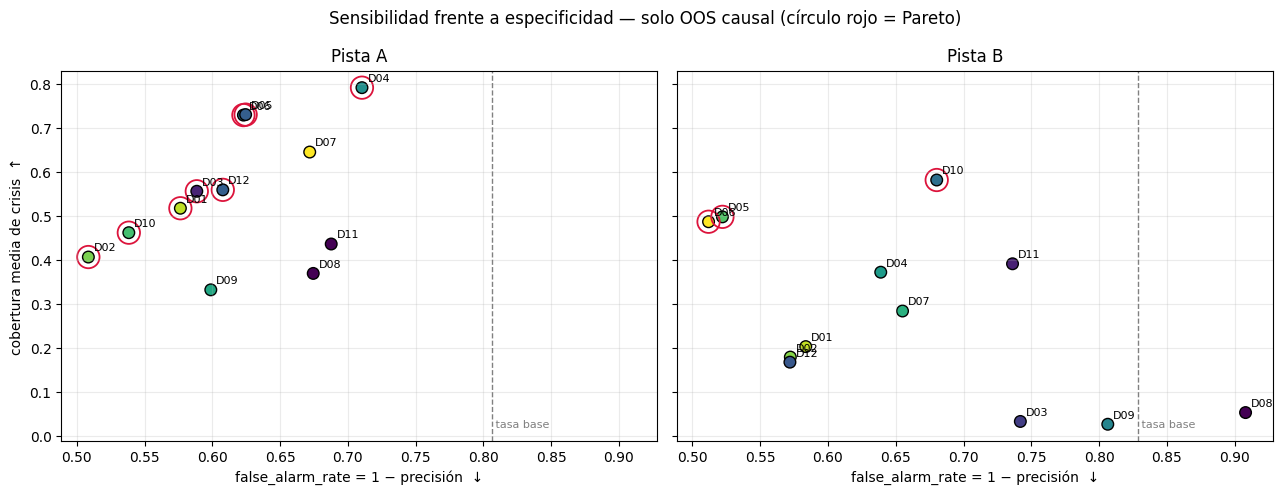

In [6]:
def far_base(track):
    part = metrics[metrics.pista == track].iloc[0]
    days = pd.bdate_range(part.oos_start, part.oos_end)
    inside = np.zeros(len(days), dtype=bool)
    for a, b in SPEC['crisis_windows'][f'pista_{track}'].values():
        inside |= (days >= pd.Timestamp(a)) & (days <= pd.Timestamp(b))
    return 1 - inside.mean()

def pareto(part):
    cov, far = part.mean_crisis_coverage.values, part.false_alarm_rate.values
    keep = []
    for i in range(len(part)):
        dominated = ((cov >= cov[i]) & (far <= far[i]) & ((cov > cov[i]) | (far < far[i]))).any()
        keep.append(not dominated)
    return np.array(keep)

if LISTO_COMPARAR:
    FAR_BASE = {t: far_base(t) for t in ['A', 'B']}
    comparison['far_base_aprox'] = comparison.pista.map(FAR_BASE)
    comparison['lift_precision'] = (1 - comparison.false_alarm_rate) / (1 - comparison.far_base_aprox)
    comparison['pareto_cov_far'] = False
    for t in ['A', 'B']:
        mask = comparison.pista == t
        comparison.loc[mask, 'pareto_cov_far'] = pareto(comparison[mask])
    display(comparison[['pista', 'id', 'mean_crisis_coverage', 'false_alarm_rate',
                        'far_base_aprox', 'lift_precision', 'pareto_cov_far']]
            .sort_values(['pista', 'lift_precision'], ascending=[True, False]).round(3))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
    for ax, track in zip(axes, ['A', 'B']):
        part = comparison[comparison.pista == track]
        ax.scatter(part.false_alarm_rate, part.mean_crisis_coverage,
                   s=70, c=part.puesto_pista, cmap='viridis_r', edgecolor='black')
        front = part[part.pareto_cov_far]
        ax.scatter(front.false_alarm_rate, front.mean_crisis_coverage, s=260,
                   facecolors='none', edgecolors='crimson', linewidths=1.3)
        ax.axvline(FAR_BASE[track], ls='--', color='grey', lw=1)
        ax.text(FAR_BASE[track], 0.02, ' tasa base', color='grey', fontsize=8)
        for _, row in part.iterrows():
            ax.annotate(row.id, (row.false_alarm_rate, row.mean_crisis_coverage),
                        xytext=(4, 4), textcoords='offset points', fontsize=8)
        ax.set_title(f'Pista {track}')
        ax.set_xlabel('false_alarm_rate = 1 − precisión  ↓')
        ax.grid(alpha=.25)
    axes[0].set_ylabel('cobertura media de crisis  ↑')
    fig.suptitle('Sensibilidad frente a especificidad — solo OOS causal (círculo rojo = Pareto)')
    fig.tight_layout()
    plt.show()

**Lectura.** La tasa base es alta (≈0,81 en A y ≈0,83 en B): las ventanas
`[pico, suelo]` cubren menos de una quinta parte del OOS. Todos los detectores
quedan a su izquierda, pero el margen es moderado: incluso los más precisos no
llegan a triplicar la precisión de marcar al azar. En A la frontera cobertura/precisión
es amplia (ocho detectores intercambian cobertura por precisión sin dominarse) y D7,
primero en el ranking, **no** está en ella: su puesto se apoya en los ejes de
persistencia y estabilidad (§8). En B la frontera la forman D6, D5 y D10; D6 domina a
D1 y D2 (más del doble de cobertura con menos falsas alarmas), que sin embargo
ocupan el 2º y 3º puesto del ranking.

## 5. Persistencia, estabilidad y coste

La detección útil no debe comprar cobertura mediante *flickering*. Se revisan
duración media y estabilidad junto al coste real medido. El tiempo no entra en el
ranking estadístico: sirve para decidir si una mejora marginal es operativamente
razonable. Recuérdese que `label_stability` tiene suelo 0,5 y que su valor depende
de la frecuencia de refit (§9).

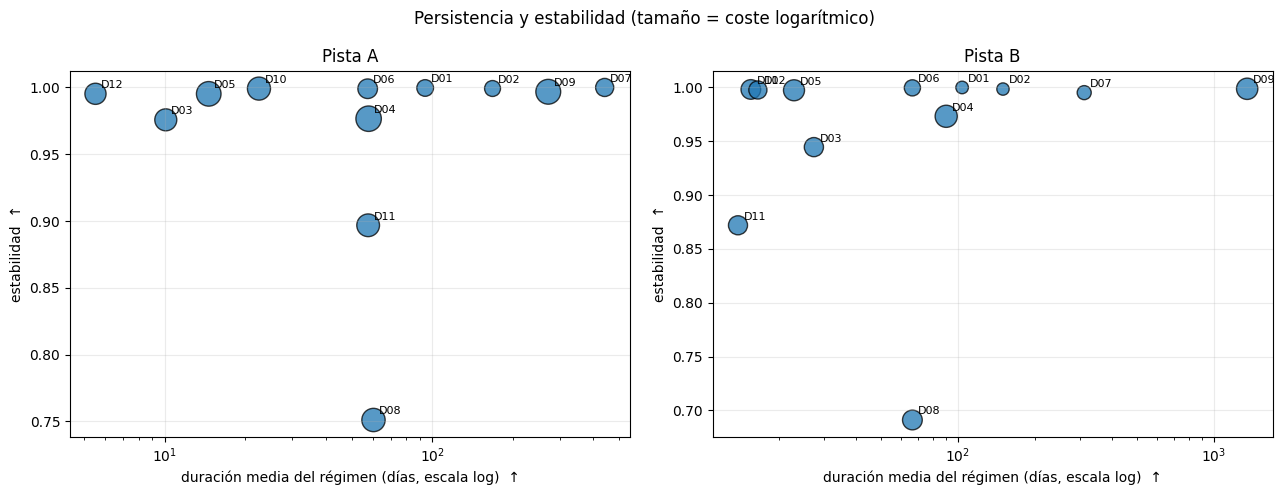

In [7]:
if LISTO_COMPARAR:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, track in zip(axes, ['A', 'B']):
        part = comparison[comparison.pista == track]
        sizes = 40 + 35 * np.log1p(part.elapsed_seconds.fillna(0))
        ax.scatter(part.mean_regime_duration, part.label_stability,
                   s=sizes, alpha=.75, edgecolor='black')
        for _, row in part.iterrows():
            ax.annotate(row.id, (row.mean_regime_duration, row.label_stability),
                        xytext=(4, 4), textcoords='offset points', fontsize=8)
        ax.set_xscale('log')
        ax.set_title(f'Pista {track}')
        ax.set_xlabel('duración media del régimen (días, escala log)  ↑')
        ax.set_ylabel('estabilidad  ↑')
        ax.grid(alpha=.25)
    fig.suptitle('Persistencia y estabilidad (tamaño = coste logarítmico)')
    fig.tight_layout()
    plt.show()

## 6. Mapa de ranks por dimensión

El mapa evita que `rank_medio` oculte especialización: una fila puede dominar en
alerta temprana y quedar atrás en persistencia. Se interpreta por pista y por eje,
nunca como evidencia de superioridad universal.

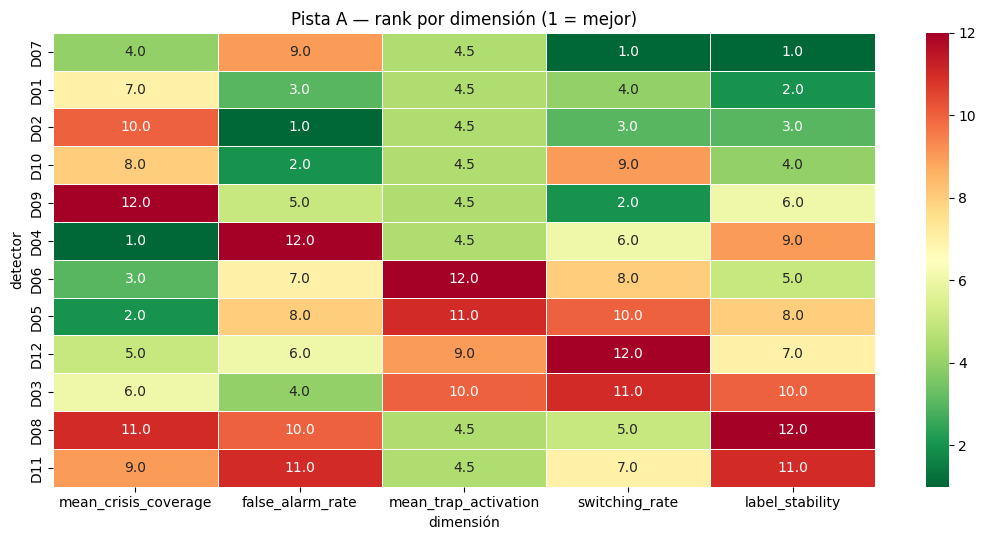

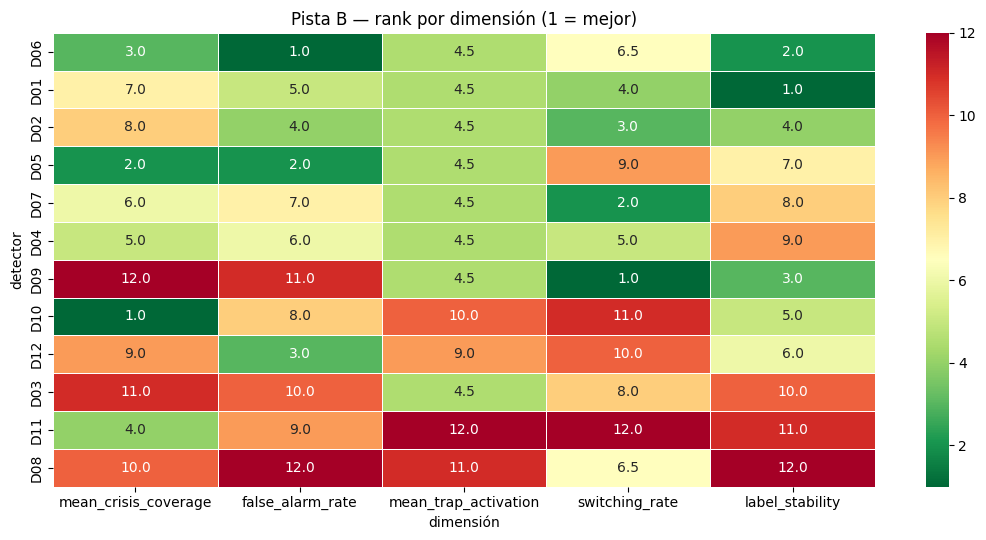

In [8]:
if LISTO_COMPARAR:
    rank_cols = [c for c in comparison if c.startswith('rank_') and c != 'rank_medio']
    for track in ['A', 'B']:
        part = comparison[comparison.pista == track].set_index('id')[rank_cols]
        part.columns = [c.removeprefix('rank_') for c in part.columns]
        plt.figure(figsize=(11, 5.5))
        sns.heatmap(part, annot=True, fmt='.1f', cmap='RdYlGn_r', linewidths=.4)
        plt.title(f'Pista {track} — rank por dimensión (1 = mejor)')
        plt.xlabel('dimensión')
        plt.ylabel('detector')
        plt.tight_layout()
        plt.show()

## 7. Cobertura por crisis

La media esconde qué episodios ve cada detector. El mapa muestra `cov_<crisis>` por
detector (filas ordenadas por puesto) y crisis (columnas cronológicas); las crisis
fuera del OOS no aparecen. La tabla inferior resume, por crisis, cuántos detectores
cubren al menos la mitad de la ventana.

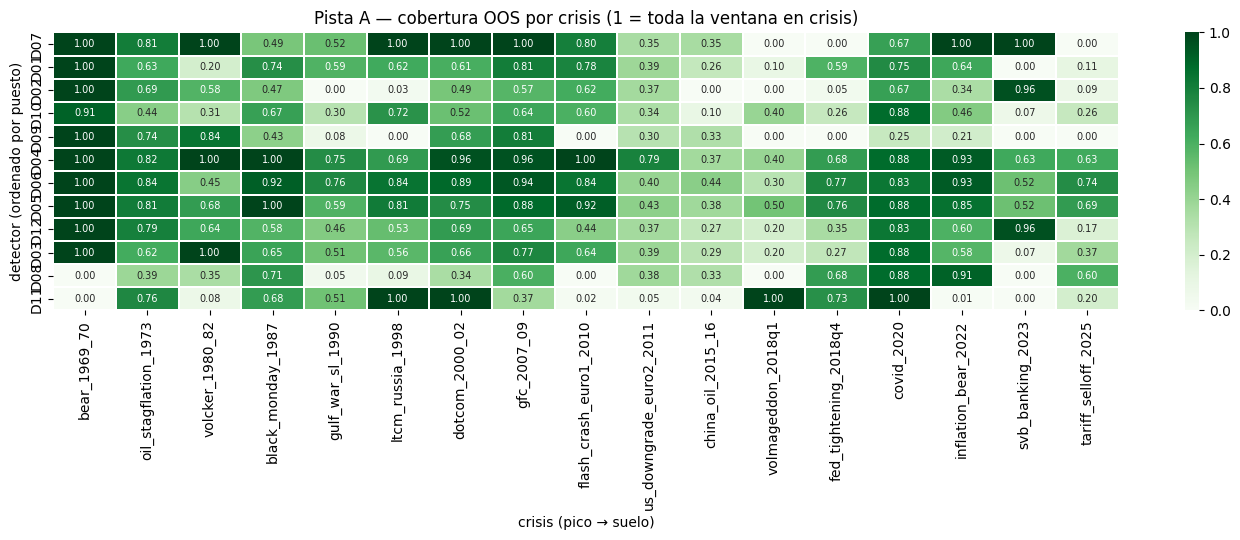

,bear_1969_70,oil_stagflation_1973,volcker_1980_82,black_monday_1987,gulf_war_sl_1990,ltcm_russia_1998,dotcom_2000_02,gfc_2007_09,flash_crash_euro1_2010,us_downgrade_euro2_2011,china_oil_2015_16,volmageddon_2018q1,fed_tightening_2018q4,covid_2020,inflation_bear_2022,svb_banking_2023,tariff_selloff_2025
detectores_con_cov≥0.5,10.0,10.00,7.00,9.00,7.00,9.00,10.00,11.00,8.00,1.00,0.00,2.0,6.00,11.00,8.00,6.0,4.00
mediana_cov,1.0,0.75,0.61,0.67,0.51,0.66,0.68,0.79,0.63,0.37,0.31,0.2,0.47,0.85,0.62,0.3,0.23


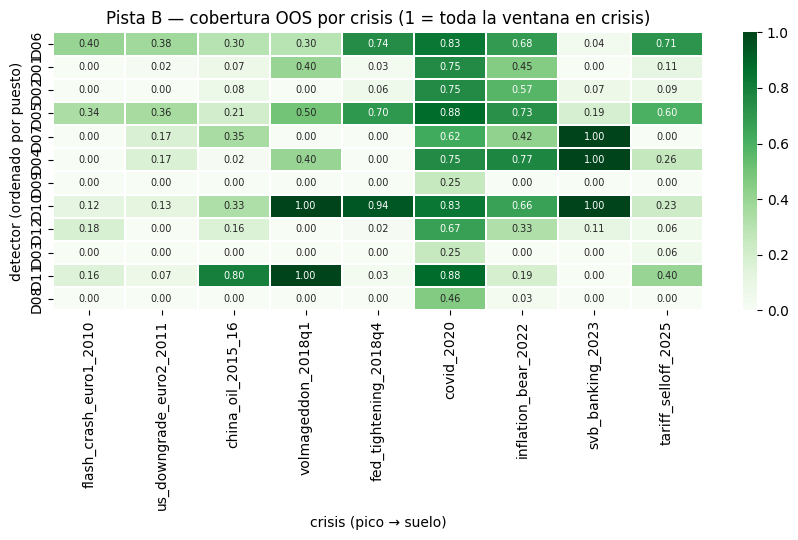

,flash_crash_euro1_2010,us_downgrade_euro2_2011,china_oil_2015_16,volmageddon_2018q1,fed_tightening_2018q4,covid_2020,inflation_bear_2022,svb_banking_2023,tariff_selloff_2025
detectores_con_cov≥0.5,0.0,0.00,1.00,3.00,3.00,9.00,5.00,3.00,2.0
mediana_cov,0.0,0.05,0.12,0.15,0.02,0.75,0.44,0.06,0.1


In [9]:
if LISTO_COMPARAR:
    for track in ['A', 'B']:
        part = comparison[comparison.pista == track].set_index('id')
        cols = [f'cov_{c}' for c in SPEC['crisis_windows'][f'pista_{track}']
                if part[f'cov_{c}'].notna().any()]
        heat = part[cols].rename(columns=lambda c: c.removeprefix('cov_'))
        plt.figure(figsize=(max(8, 0.65 * len(cols) + 3), 5.5))
        sns.heatmap(heat, annot=True, fmt='.2f', cmap='Greens', vmin=0, vmax=1,
                    linewidths=.3, annot_kws={'fontsize': 7})
        plt.title(f'Pista {track} — cobertura OOS por crisis (1 = toda la ventana en crisis)')
        plt.xlabel('crisis (pico → suelo)')
        plt.ylabel('detector (ordenado por puesto)')
        plt.tight_layout()
        plt.show()
        vistas = (heat >= 0.5).sum().rename('detectores_con_cov≥0.5')
        display(pd.concat([vistas, heat.median().rename('mediana_cov').round(2)], axis=1).T)

**Lectura.**

- **A.** Los grandes bear markets (1973, dotcom, GFC, 2022) y el COVID los cubre la
  mayoría de familias (8–11 de 12 detectores con cobertura ≥ 0,5). La discriminación
  está en los episodios cortos o atípicos: `us_downgrade_euro2_2011` y
  `china_oil_2015_16` (como mucho un detector ≥ 0,5), `volmageddon_2018q1` (dos),
  `tariff_selloff_2025` (cuatro). D7 (CUSUM) cubre por completo los bear lentos y la
  crisis SVB, pero no marca volmageddon, fed_tightening ni tariff: es un detector de
  régimen persistente, no una alarma rápida. D4 tiene la cobertura más amplia, a costa
  de la mayor tasa de falsas alarmas.
- **B.** Ningún detector cubre la mitad de `flash_crash_euro1_2010` ni de
  `us_downgrade_euro2_2011`; los que más se acercan son los modelos de varianza D6 y D5
  (≈0,35–0,40). D3, D8 y D9 prácticamente no marcan crisis fuera de muestra (cobertura
  media ≤ 0,05). Un diagnóstico de revisión sobre D3 y D8 muestra que su estado de crisis
  ocupa ≈12–14 % del entrenamiento pero ≈1–4 % del OOS: se aprende en un train inicial de
  tres años dominado por la GFC (2007–2010) y los episodios posteriores no alcanzan esa
  región del espacio de features. Es un efecto del diseño de la pista B, no solo del
  modelo.

## 8. Robustez del ranking

Tres pruebas, todas sobre las métricas ya calculadas (no se reajusta nada):

1. **Líneas base triviales.** Se añaden dos detectores sin información: `SIEMPRE_CALMA`
   (nunca marca crisis: cobertura 0, FAR indefinido → al fondo, trampas 0, switching 0,
   estabilidad 1) y `SIEMPRE_CRISIS` (cobertura 1, FAR = tasa base, trampas 1,
   switching 0, estabilidad 1). Un ranking sano debería dejarlos al fondo.
2. **Quitar un eje cada vez** (y quedarse solo con cobertura + FAR).
3. **Quitar una crisis cada vez** (*leave-one-crisis-out*) sobre la cobertura media.

Estas filas **no** se exportan: `ranking_v2.csv` sigue siendo el ranking oficial.

In [10]:
def rank_axes(df, axes):
    out = df.copy()
    cols = []
    for metric in axes:
        col = f'r_{metric}'
        out[col] = out.groupby('pista')[metric].rank(
            ascending=AXES[metric], method='average', na_option='bottom')
        cols.append(col)
    out['rank_medio_var'] = out[cols].mean(axis=1)
    out['puesto_var'] = out.groupby('pista')['rank_medio_var'].rank(method='min')
    return out.set_index(['pista', 'id'])['puesto_var']

if LISTO_COMPARAR:
    base_rows = []
    for t in ['A', 'B']:
        for name, cov, far, trap in [('SIEMPRE_CALMA', 0.0, np.nan, 0.0),
                                     ('SIEMPRE_CRISIS', 1.0, FAR_BASE[t], 1.0)]:
            base_rows.append({'pista': t, 'id': name, 'mean_crisis_coverage': cov,
                              'false_alarm_rate': far, 'mean_trap_activation': trap,
                              'switching_rate': 0.0, 'label_stability': 1.0})
    with_baselines = pd.concat(
        [comparison[['pista', 'id', *AXES]], pd.DataFrame(base_rows)], ignore_index=True)
    puestos_base = rank_axes(with_baselines, list(AXES)).rename('puesto_con_lineas_base')
    tabla_base = (with_baselines.set_index(['pista', 'id']).join(puestos_base)
                  .reset_index().sort_values(['pista', 'puesto_con_lineas_base']))
    display(tabla_base.round(3))
    for t in ['A', 'B']:
        p = puestos_base.loc[t]
        peores = [i for i in p.index if i.startswith('D') and p[i] > p['SIEMPRE_CALMA']]
        print(f"Pista {t}: SIEMPRE_CRISIS queda {int(p['SIEMPRE_CRISIS'])}º y SIEMPRE_CALMA "
              f"{int(p['SIEMPRE_CALMA'])}º de 14; detectores por debajo de SIEMPRE_CALMA: {', '.join(sorted(peores))}")

,pista,id,mean_crisis_coverage,false_alarm_rate,mean_trap_activation,switching_rate,label_stability,puesto_con_lineas_base
0,A,D07,0.646,0.672,0.000,0.002,1.000,1.0
1,A,D01,0.519,0.576,0.000,0.011,1.000,2.0
2,A,D02,0.408,0.508,0.000,0.006,0.999,3.0
25,A,SIEMPRE_CRISIS,1.000,0.806,1.000,0.000,1.000,4.0
3,A,D10,0.463,0.538,0.000,0.044,0.999,5.0
4,A,D09,0.333,0.599,0.000,0.004,0.997,6.0
24,A,SIEMPRE_CALMA,0.000,NaN,0.000,0.000,1.000,7.0
5,A,D04,0.793,0.710,0.000,0.017,0.977,8.0
6,A,D06,0.730,0.623,0.079,0.017,0.999,9.0
7,A,D05,0.731,0.625,0.032,0.068,0.995,10.0


Pista A: SIEMPRE_CRISIS queda 4º y SIEMPRE_CALMA 7º de 14; detectores por debajo de SIEMPRE_CALMA: D03, D04, D05, D06, D08, D11, D12
Pista B: SIEMPRE_CRISIS queda 4º y SIEMPRE_CALMA 8º de 14; detectores por debajo de SIEMPRE_CALMA: D03, D08, D09, D10, D11, D12


In [11]:
if LISTO_COMPARAR:
    base = comparison[['pista', 'id', *AXES]]
    variantes = {'oficial': rank_axes(base, list(AXES))}
    for metric in AXES:
        variantes[f'sin_{metric}'] = rank_axes(base, [m for m in AXES if m != metric])
    variantes['solo_cobertura+FAR'] = rank_axes(base, ['mean_crisis_coverage', 'false_alarm_rate'])
    sens_ejes = pd.DataFrame(variantes)
    sens_ejes['puesto_min'] = sens_ejes.min(axis=1)
    sens_ejes['puesto_max'] = sens_ejes.max(axis=1)
    display(sens_ejes.sort_values(['pista', 'oficial']).astype(int))

    loco = {}
    for t in ['A', 'B']:
        part = metrics[metrics.pista == t]
        crisis_cols = [c for c in part if c.startswith('cov_') and not c.endswith(('_lo', '_hi'))
                       and part[c].notna().any()]
        for c in crisis_cols:
            alt = metrics.copy()
            alt.loc[alt.pista == t, c] = np.nan
            r = bm.rank_within_track(alt)
            loco[(t, c)] = r[r.pista == t].set_index('id')['puesto_pista']
    loco_tab = pd.DataFrame({t: pd.concat([loco[k] for k in loco if k[0] == t], axis=1)
                             .agg(['min', 'max'], axis=1).apply(lambda s: f"{int(s['min'])}–{int(s['max'])}", axis=1)
                             for t in ['A', 'B']})
    loco_tab.index.name = 'id'
    print('Rango de puestos al quitar una crisis cada vez (leave-one-crisis-out):')
    display(loco_tab)

oficial  sin_mean_crisis_coverage  sin_false_alarm_rate  \
pista id                                                             
A     D07        1                         3                     1   
      D01        2                         2                     2   
      D02        3                         1                     3   
      D10        4                         5                     6   
      D09        5                         4                     5   
      D04        6                         6                     3   
      D06        7                         8                     7   
      D05        8                        12                     8   
      D12        8                        10                    11   
      D03       10                        11                    12   
      D08       11                         6                    10   
      D11       11                         9                     9   
B     D06        1                         1                     1   
      D01        2                         2                     2   
      D02        3                         3                     3   
      D05        4                         6                     6   
      D07        5                         5                     4   
      D04        6                         7                     7   
      D09        7                         4                     4   
      D10        8                        10                     8   
      D12        9                         8                    10   
      D03       10                         9                     9   
      D11       11                        12                    11   
      D08       12                        11                    12   

           sin_mean_trap_activation  sin_switching_rate  sin_label_stability  \
pista id                                                                       
A     D07                         1                   2                    1   
      D01                         2                   1                    1   
      D02                         3                   2                    1   
      D10                         4                   2                    4   
      D09                         6                   8                    4   
      D04                         7                   5                    4   
      D06                         4                   6                    7   
      D05                         7                   9                    9   
      D12                         9                   6                   12   
      D03                        10                  10                    9   
      D08                        11                  12                    8   
      D11                        11                  11                   11   
B     D06                         1                   1                    1   
      D01                         2                   3                    5   
      D02                         3                   4                    3   
      D05                         4                   2                    2   
      D07                         5                   7                    3   
      D04                         6                   6                    5   
      D09                         8                   9                    7   
      D10                         6                   5                    8   
      D12                         9                   8                    9   
      D03                        11                  10                   10   
      D11                        10                  11                   11   
      D08                        12                  12                   12   

           solo_cobertura+FAR  puesto_min  puesto_max  
pista id                                             

Rango de puestos al quitar una crisis cada vez (leave-one-crisis-out):


,A,B
id,,
D01,1–2,2–3
D02,2–3,2–3
D03,9–10,10–10
D04,6–6,6–6
D05,8–9,3–4
D06,7–7,1–1
D07,1–1,5–5
D08,11–12,12–12
D09,4–5,7–7


**Lectura de la robustez.**

- **Las líneas base triviales no quedan al fondo.** `SIEMPRE_CRISIS` sería 4º en ambas
  pistas y `SIEMPRE_CALMA` queda por delante de la mitad inferior de la tabla. La razón es
  estructural: tres de los cinco ejes (trampas, switching y estabilidad) premian la
  **inactividad** o la **constancia**, así que un detector que no hace nada gana tres ejes.
  `rank_medio` es por tanto un resumen de disciplina más que de detección, y no debe
  leerse como "calidad de detector".
- **Podios.** B es robusto: D6 es 1º en todas las variantes de ejes y en todas las de
  *leave-one-crisis-out*. En A el primer puesto de D7 depende de los ejes de
  persistencia: sin la cobertura cae a 3º y con solo cobertura + FAR a 8º; D1 está
  entre 1º y 2º en todas las variantes de ejes, lo que lo hace el candidato más estable
  del podio de A.
- **Crisis individuales.** Quitar una crisis cada vez apenas mueve los puestos (como
  mucho ±1–2 posiciones): el ranking no depende de un único episodio.

## 9. Limitaciones que condicionan la lectura

1. **Ranking sesgado hacia la inactividad** (§8): 3 de 5 ejes premian no cambiar de
   estado. Se recomienda complementar con un criterio de detección explícito (p. ej.
   cobertura con FAR acotado, o precisión/recall por evento) antes de decidir.
2. **Autómatas reiniciados en cada refit.** D1, D2, D6 y D10 son reglas con histéresis
   y permanencia mínima cuyo autómata arranca en calma al inicio de cada bloque OOS;
   D7 sí propaga su CUSUM desde el train. En A, la mayoría de las salidas de crisis de
   D1 y D2 coinciden con un inicio de bloque. Es causal, pero penaliza su cobertura e
   infla su switching. Una estimación de revisión, fuera de este notebook y propagando
   el estado con 252 sesiones de contexto, sube la cobertura de D1 en A de 0,52 a 0,60
   (y la de D2 en B de 0,18 a 0,29), y D1 pasaría a 1º en A. No se ha aplicado: cambiarlo
   exige re-ejecutar el benchmark.
3. **`false_alarm_rate` es `1 − precisión`** con ventanas `[pico, suelo]`: todo lo marcado
   en la fase de recuperación tras el suelo (volatilidad aún alta) cuenta como falsa
   alarma. Castiga especialmente a los detectores de volatilidad.
4. **Cobertura media no ponderada**: un episodio de 10 sesiones pesa igual que uno de
   600, y `bear_1969_70` (A) entra con solo sus últimos días.
5. **`label_stability`** vive en [0,5; 1], se concentra cerca de 1 y depende de la
   frecuencia de refit: D5 (63), D8 y D11 (126, D11 con ventana móvil) comparan contra un
   modelo que ha visto mucho más dato nuevo que los de refit mensual.
6. **Trampas** solo dos, ambas en 2013 y casi siempre a 0: el eje apenas discrimina y
   se resuelve casi todo por empates.
7. **B sin la GFC fuera de muestra** y con un entrenamiento inicial de tres años dominado
   por ella: los modelos de clustering/estado latente (D3, D8, D9) quedan anclados a esa
   crisis.
8. **Pocos eventos** (17 en A, 9 en B): no hay contraste de significación entre
   detectores; los IC bootstrap de `cov_*_lo/hi` son intra-evento, no entre eventos.
9. **BIC, silueta y logL** se calculan con un ajuste final in-sample y features distintas
   por detector: no son comparables entre detectores y no entran en el ranking.

## 10. Qué se decide después — no en este notebook

La evidencia anterior permite formular tres alternativas, pero no escogerlas antes
de ver un benchmark completo y comparable:

1. **Detector único:** si un modelo domina de forma estable en ambas pistas. Ninguno lo
   hace: el mejor de B (D6) es 7º en A y el mejor de A (D7) es 5º en B.
2. **Híbrido de dos velocidades:** un núcleo de régimen persistente (p. ej. D7 o D8)
   acompañado por una alarma rápida (reglas de volatilidad D1/D2 o D6), si sus errores
   son complementarios. §7 sugiere que lo son: D7 no ve los episodios cortos que sí ven
   D1/D6.
3. **Detector nuevo:** solo si ningún candidato satisface simultáneamente cobertura,
   disciplina y estabilidad, y siempre comparado contra estos baselines.

La decisión deberá escribirse en una ADR y congelar modelo, features, hiperparámetros
y regla de refit. Después se realizará la prueba pseudolive diaria sobre un periodo
final no utilizado para elegir esa configuración.

In [12]:
if LISTO_COMPARAR:
    podium = comparison.loc[comparison['puesto_pista'] <= 3, scorecard_cols]
    print('Podio descriptivo por pista (no decisión final):')
    display(podium.round(4))
    for t in ['A', 'B']:
        top = comparison[(comparison.pista == t) & (comparison.puesto_pista == 1)].iloc[0]
        print(f"Pista {t}: 1º {top.id} ({top.detector}) — cobertura {top.mean_crisis_coverage:.3f}, "
              f"FAR {top.false_alarm_rate:.3f}, switching {top.switching_rate:.4f}, "
              f"estabilidad {top.label_stability:.4f}, rank_medio {top.rank_medio:.2f}")
else:
    print('Pendiente: completar y validar 04_benchmark_detectores.ipynb.')

Podio descriptivo por pista (no decisión final):


,pista,puesto_pista,id,detector,familia,mean_crisis_coverage,false_alarm_rate,mean_trap_activation,switching_rate,mean_regime_duration,label_stability,elapsed_seconds,rank_medio
6,A,1.0,D07,changepoint_online,Change-point,0.6463,0.6718,0.0,0.0022,441.6562,1.0000,39.9900,3.9
0,A,2.0,D01,rule_vix_threshold,Reglas,0.5185,0.5764,0.0,0.0105,94.2200,0.9996,18.5395,4.1
1,A,3.0,D02,rule_composite_riskoff,Reglas,0.4077,0.5085,0.0,0.0059,168.2500,0.9992,12.7200,4.3
17,B,1.0,D06,garch_t_vol,GARCH,0.4879,0.5119,0.0,0.0148,66.5410,0.9995,14.3589,3.4
12,B,2.0,D01,rule_vix_threshold,Reglas,0.2042,0.5836,0.0,0.0094,104.0769,0.9999,2.2981,4.3
13,B,3.0,D02,rule_composite_riskoff,Reglas,0.1804,0.5722,0.0,0.0064,150.3333,0.9984,2.0367,4.7


Pista A: 1º D07 (changepoint_online) — cobertura 0.646, FAR 0.672, switching 0.0022, estabilidad 1.0000, rank_medio 3.90
Pista B: 1º D06 (garch_t_vol) — cobertura 0.488, FAR 0.512, switching 0.0148, estabilidad 0.9995, rank_medio 3.40


## 11. Cierre

`05_comparacion_detectores.ipynb` produce una comparación reproducible, no una
conclusión automática. El entregable de esta etapa son el master v2, el ranking por
dimensiones, los gráficos, las pruebas de robustez y la lista explícita de
limitaciones.

Solo después de revisar esa evidencia se decidirá si el TFM adopta uno de los doce,
combina dos mecanismos o justifica un detector nuevo.